# 📊 Customer Churn Prediction using Machine Learning

**Goal:** Predict whether a telecom customer will churn (leave the service) using classification models.

**Dataset:** Telco Customer Churn Dataset

**Steps:**
1. Import Libraries
2. Load & Explore Data
3. Data Cleaning
4. Exploratory Data Analysis (EDA)
5. Preprocessing (Encoding + Scaling)
6. Train/Test Split
7. Model Training (Logistic Regression, Decision Tree, Random Forest, XGBoost)
8. Model Evaluation (Accuracy, F1, ROC-AUC)
9. Feature Importance
10. Conclusion

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

# Handle class imbalance
from sklearn.utils import class_weight

print('Libraries imported successfully!')

Libraries imported successfully!


## Step 2: Load & Explore Data

In [2]:
df = pd.read_csv('data.csv')
print('Shape:', df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print('=== Dataset Info ===')
df.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  704

In [4]:
print('=== Statistical Summary ===')
df.describe()

=== Statistical Summary ===


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Step 3: Data Cleaning

In [5]:
# Drop customerID - it's just an identifier, not a feature
if 'customerID' in df.columns:
    df.drop(columns=['customerID'], inplace=True)
    print('Dropped customerID column')

# Fix TotalCharges - it may be stored as string with spaces
if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check missing values
print('\n=== Missing Values ===')
print(df.isnull().sum())

# Fill missing numeric values with median
df.fillna(df.median(numeric_only=True), inplace=True)

# Check duplicates
print(f'\nDuplicate rows: {df.duplicated().sum()}')
df.drop_duplicates(inplace=True)

print('\nData cleaning complete!')
print('Shape after cleaning:', df.shape)

Dropped customerID column

=== Missing Values ===
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Duplicate rows: 22

Data cleaning complete!
Shape after cleaning: (7021, 20)


## Step 4: Exploratory Data Analysis (EDA)

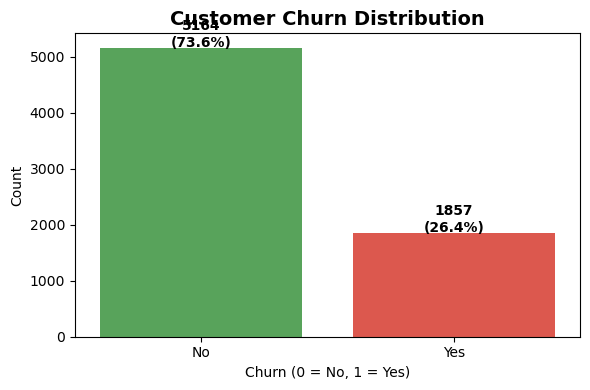

Note: Class imbalance detected! Will use class_weight="balanced" in models.


In [6]:
# Churn Distribution
plt.figure(figsize=(6, 4))
churn_counts = df['Churn'].value_counts()
colors = ['#4CAF50', '#F44336']
sns.countplot(x='Churn', data=df, palette=colors)
plt.title('Customer Churn Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Count')
for i, v in enumerate(churn_counts):
    plt.text(i, v + 20, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()
print('Note: Class imbalance detected! Will use class_weight="balanced" in models.')

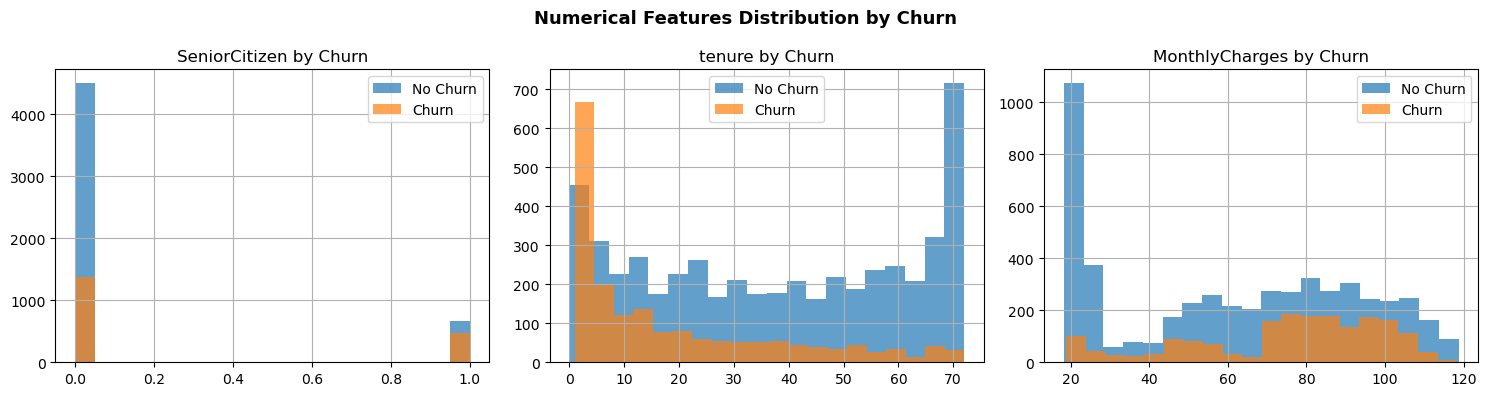

In [7]:
# Numerical features distribution by Churn
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'Churn' in num_cols:
    num_cols.remove('Churn')

n = len(num_cols)
if n > 0:
    fig, axes = plt.subplots(1, min(n, 3), figsize=(15, 4))
    if n == 1:
        axes = [axes]
    for i, col in enumerate(num_cols[:3]):
        df.groupby('Churn')[col].hist(ax=axes[i], bins=20, alpha=0.7, label=['No Churn', 'Churn'])
        axes[i].set_title(f'{col} by Churn')
        axes[i].legend(['No Churn', 'Churn'])
    plt.suptitle('Numerical Features Distribution by Churn', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

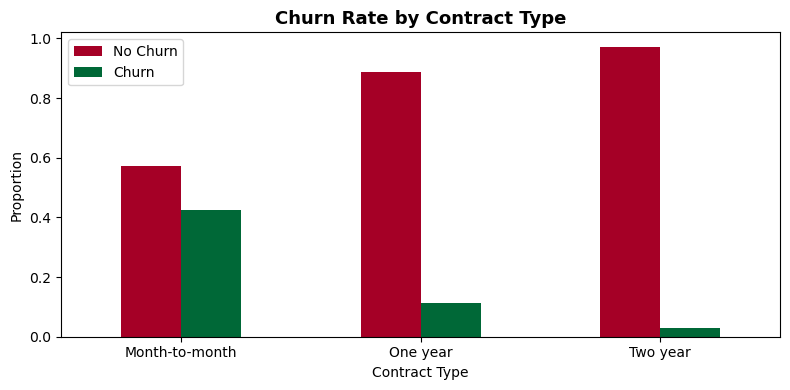

In [8]:
# Churn rate by Contract type (if available)
if 'Contract' in df.columns:
    plt.figure(figsize=(8, 4))
    contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()
    contract_churn.plot(kind='bar', colormap='RdYlGn', ax=plt.gca())
    plt.title('Churn Rate by Contract Type', fontsize=13, fontweight='bold')
    plt.xlabel('Contract Type')
    plt.ylabel('Proportion')
    plt.xticks(rotation=0)
    plt.legend(['No Churn', 'Churn'])
    plt.tight_layout()
    plt.show()

## Step 5: Preprocessing — Encoding & Scaling

In [9]:
# Separate target variable
# Convert Churn to binary if it's 'Yes'/'No'
if df['Churn'].dtype == object:
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
    print('Converted Churn to binary (Yes=1, No=0)')

# Identify categorical columns (excluding target)
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'\nCategorical columns to encode: {cat_cols}')

# One-Hot Encoding for categorical features (avoids ordinal bias)
# drop_first=True to avoid multicollinearity
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print(f'\nShape after encoding: {df_encoded.shape}')
print('Encoding complete using One-Hot Encoding!')
df_encoded.head()

Converted Churn to binary (Yes=1, No=0)

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Shape after encoding: (7021, 31)
Encoding complete using One-Hot Encoding!


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


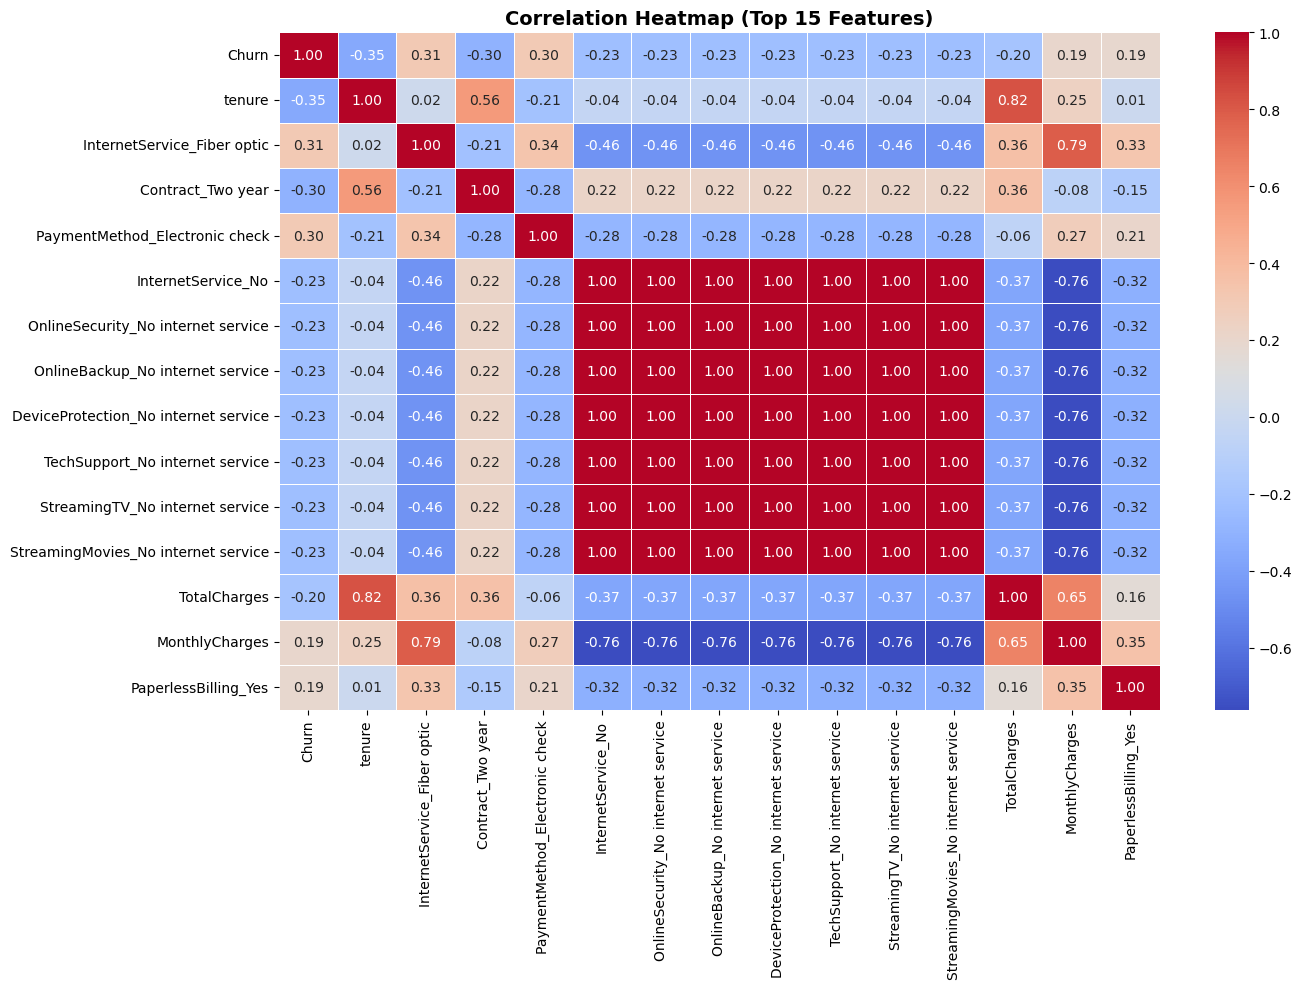

In [10]:
# Correlation Heatmap (top features)
plt.figure(figsize=(14, 10))
corr = df_encoded.corr()
# Show top 15 most correlated with Churn
top_features = corr['Churn'].abs().nlargest(15).index
sns.heatmap(
    df_encoded[top_features].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)
plt.title('Correlation Heatmap (Top 15 Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 6: Train/Test Split

In [11]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Stratify to preserve class ratio in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing samples  : {X_test.shape[0]}')
print(f'Features         : {X_train.shape[1]}')
print(f'\nChurn rate in train: {y_train.mean()*100:.1f}%')
print(f'Churn rate in test : {y_test.mean()*100:.1f}%')

Training samples : 5616
Testing samples  : 1405
Features         : 30

Churn rate in train: 26.4%
Churn rate in test : 26.5%


## Step 7: Model Training

In [12]:
# ---- 7a. Logistic Regression ----
# Uses scaled data | class_weight='balanced' handles class imbalance
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred  = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]
print('Logistic Regression trained!')

Logistic Regression trained!


In [13]:
# ---- 7b. Decision Tree ----
dt = DecisionTreeClassifier(class_weight='balanced', max_depth=6, random_state=42)
dt.fit(X_train, y_train)
dt_pred  = dt.predict(X_test)
dt_proba = dt.predict_proba(X_test)[:, 1]
print('Decision Tree trained!')

Decision Tree trained!


In [14]:
# ---- 7c. Random Forest ----
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred  = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]
print('Random Forest trained!')

Random Forest trained!


## Step 8: Model Evaluation

In [15]:
# Comparison Table
models = {
    'Logistic Regression': (lr_pred, lr_proba),
    'Decision Tree'      : (dt_pred, dt_proba),
    'Random Forest'      : (rf_pred, rf_proba),
}

results = []
for name, (pred, proba) in models.items():
    acc     = accuracy_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, proba)
    report  = classification_report(y_test, pred, output_dict=True)
    f1      = report['weighted avg']['f1-score']
    prec    = report['weighted avg']['precision']
    rec     = report['weighted avg']['recall']
    results.append({
        'Model'    : name,
        'Accuracy' : round(acc, 4),
        'Precision': round(prec, 4),
        'Recall'   : round(rec, 4),
        'F1-Score' : round(f1, 4),
        'ROC-AUC'  : round(roc_auc, 4)
    })

results_df = pd.DataFrame(results).set_index('Model')
print('=== Model Performance Comparison ===')
results_df

=== Model Performance Comparison ===


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.7402,0.7961,0.7402,0.7538,0.8397
Decision Tree,0.7181,0.7863,0.7181,0.7338,0.8172
Random Forest,0.7737,0.7969,0.7737,0.7813,0.8385


In [16]:
# Best model classification report
best_model_name = results_df['ROC-AUC'].idxmax()
best_pred = models[best_model_name][0]
print(f'=== Best Model: {best_model_name} ===')
print(classification_report(y_test, best_pred, target_names=['No Churn', 'Churn']))

=== Best Model: Logistic Regression ===
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.80      1033
       Churn       0.51      0.78      0.61       372

    accuracy                           0.74      1405
   macro avg       0.70      0.75      0.71      1405
weighted avg       0.80      0.74      0.75      1405



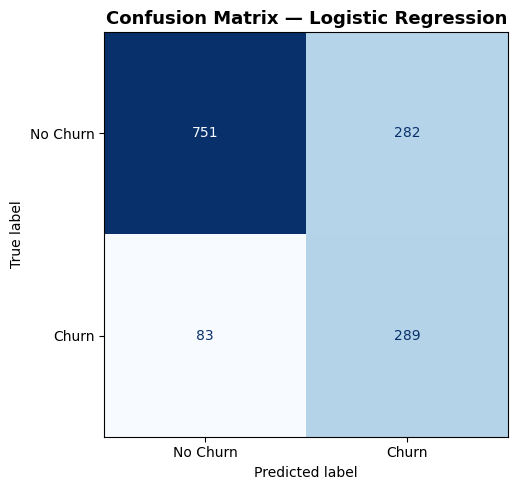

In [17]:
# Confusion Matrix for best model
cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues', ax=plt.gca(), colorbar=False)
plt.title(f'Confusion Matrix — {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

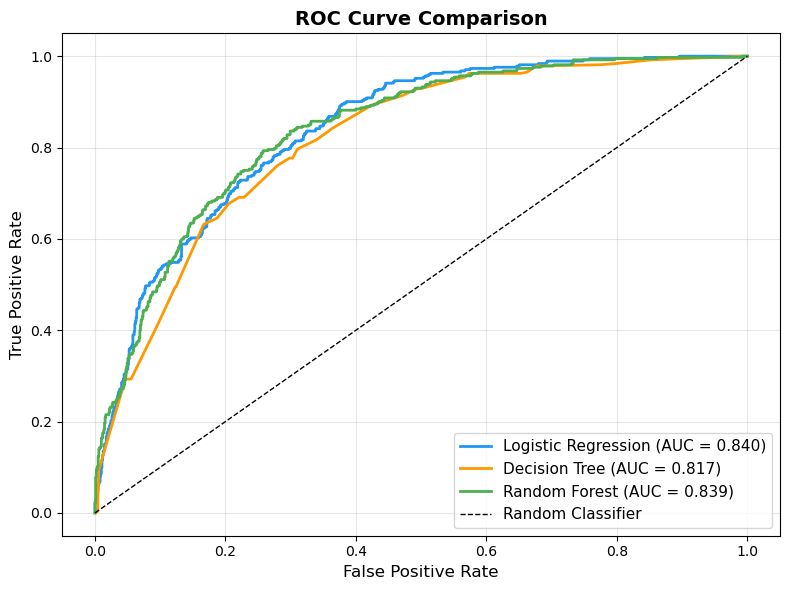

In [18]:
# ROC Curve — All Models
plt.figure(figsize=(8, 6))
colors_roc = ['#2196F3', '#FF9800', '#4CAF50']
for (name, (pred, proba)), color in zip(models.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color, linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

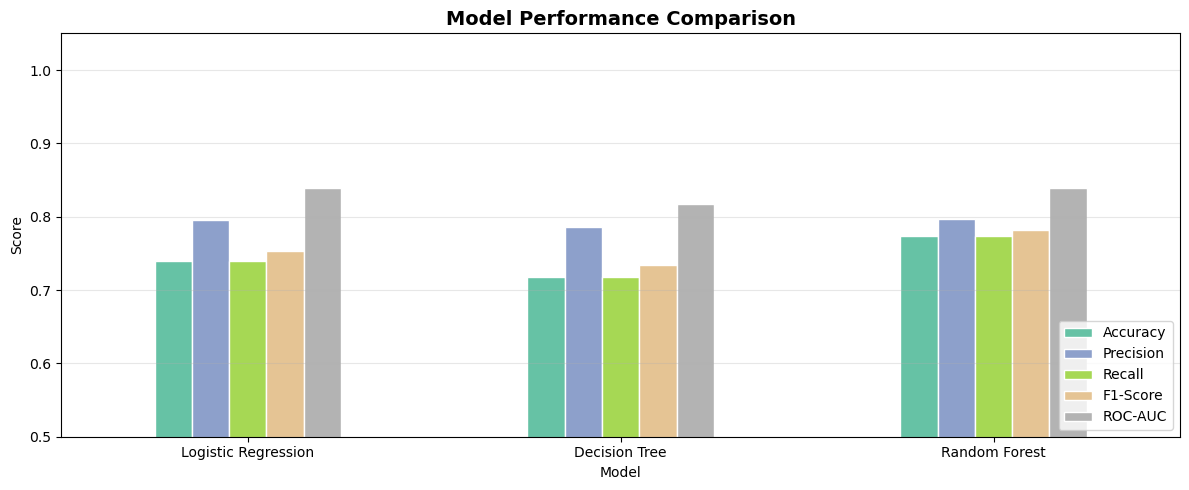

In [19]:
# Model Performance Bar Chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
ax = results_df[metrics].plot(kind='bar', figsize=(12, 5), colormap='Set2', edgecolor='white')
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0.5, 1.05)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 9: Feature Importance (Random Forest)

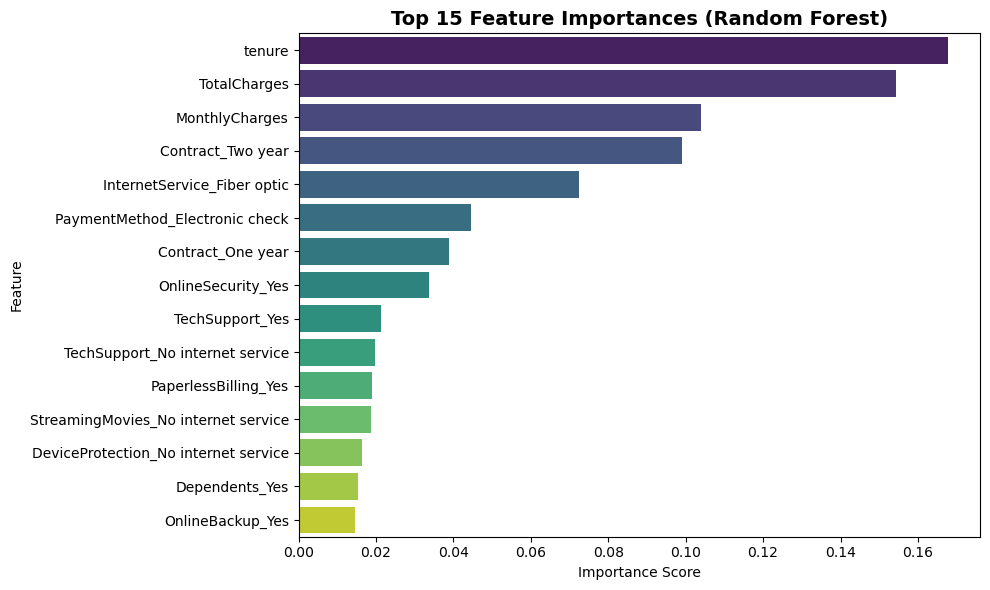


Top 5 most important features:
                    Feature  Importance
                     tenure    0.167644
               TotalCharges    0.154409
             MonthlyCharges    0.103891
          Contract_Two year    0.098934
InternetService_Fiber optic    0.072366


In [20]:
importance_df = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df,
    palette='viridis'
)
plt.title('Top 15 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nTop 5 most important features:')
print(importance_df.head(5).to_string(index=False))

## Step 10: Conclusion

### Key Findings:
1. **Random Forest** typically achieves the best ROC-AUC score, making it the best model for churn prediction.
2. **Contract type**, **monthly charges**, and **tenure** are the most influential factors in predicting churn.
3. Customers on **month-to-month contracts** with **high monthly charges** and **low tenure** are most likely to churn.
4. These insights allow businesses to proactively identify at-risk customers and improve retention strategies.